In [52]:
!pip install yfinance

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

In [53]:
tickers = ["AAPL", "MSFT", "JNJ", "JPM", "XOM", "AMZN"]

warnings.filterwarnings("ignore")

data = yf.download(tickers, start="2020-01-01", end="2025-01-01", progress=False)["Close"]
data.dropna(inplace=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(data.shape)
data.head()

(1258, 6)


Ticker,AAPL,AMZN,JNJ,JPM,MSFT,XOM
Date,,,,,,
2020-01-02,72.400536,94.900497,122.638229,118.430328,152.158401,53.306404
2020-01-03,71.696625,93.748497,121.218361,116.867477,150.263748,52.877857
2020-01-06,72.267937,95.143997,121.067177,116.774536,150.652161,53.283848
2020-01-07,71.928047,95.343002,121.806465,114.789307,149.278549,52.847771
2020-01-08,73.085106,94.598503,121.789688,115.684776,151.656342,52.050823


In [54]:
returns = data.pct_change().dropna()
expected_return = returns.mean() * 252
risk = returns.std() * np.sqrt(252)
cov_matrix = returns.cov() * 252


print("Expected Annual Return:")
print(expected_return.round(4))

print("\nRisk (Std Dev):")
print(risk.round(4))

print("\nCovariance Matrix:")
print(cov_matrix.round(6))

Expected Annual Return:
Ticker
AAPL    0.2979
AMZN    0.2327
JNJ     0.0452
JPM     0.1879
MSFT    0.2489
XOM     0.1913
dtype: float64

Risk (Std Dev):
Ticker
AAPL    0.3168
AMZN    0.3596
JNJ     0.1966
JPM     0.3253
MSFT    0.3050
XOM     0.3438
dtype: float64

Covariance Matrix:
Ticker      AAPL      AMZN       JNJ       JPM      MSFT       XOM
Ticker                                                            
AAPL    0.100354  0.067469  0.023303  0.042290  0.072297  0.030696
AMZN    0.067469  0.129341  0.012666  0.031115  0.074418  0.016162
JNJ     0.023303  0.012666  0.038638  0.026271  0.022720  0.020314
JPM     0.042290  0.031115  0.026271  0.105798  0.041789  0.063511
MSFT    0.072297  0.074418  0.022720  0.041789  0.093008  0.025385
XOM     0.030696  0.016162  0.020314  0.063511  0.025385  0.118196


In [55]:
num_portfolios = 5000
num_assets = len(expected_return)
portfolio_returns = []
portfolio_risks = []
portfolio_weights = []

for _ in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    port_return = np.dot(weights, expected_return)
    port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))

    portfolio_returns.append(port_return)
    portfolio_risks.append(port_variance)
    portfolio_weights.append(weights)

In [56]:
lambda_values = [0.5, 2, 5]

best_results = {}

for lambda_ in lambda_values:
    best_utility = -np.inf
    best_index = -1

    for i in range(num_portfolios):
        utility = portfolio_returns[i] - 0.5 * lambda_ * portfolio_risks[i]

        if utility > best_utility:
            best_utility = utility
            best_index = i

    best_results[lambda_] = {
        "weights": portfolio_weights[best_index],
        "return": portfolio_returns[best_index],
        "risk": portfolio_risks[best_index],
        "utility": best_utility
    }

In [57]:
for lambda_, result in best_results.items():
    print(f"\n=== Lambda = {lambda_} ===")

    for i, ticker in enumerate(tickers):
        print(f"{ticker}: {result['weights'][i]:.2%}")

    print(f"Expected Return: {result['return']:.4f}")
    print(f"Risk: {result['risk']:.4f}")
    print(f"Utility: {result['utility']:.4f}")


=== Lambda = 0.5 ===
AAPL: 56.81%
MSFT: 21.58%
JNJ: 1.41%
JPM: 12.05%
XOM: 0.82%
AMZN: 7.33%
Expected Return: 0.2588
Risk: 0.0704
Utility: 0.2412

=== Lambda = 2 ===
AAPL: 44.52%
MSFT: 10.12%
JNJ: 0.51%
JPM: 4.37%
XOM: 26.40%
AMZN: 14.07%
Expected Return: 0.2573
Risk: 0.0674
Utility: 0.1899

=== Lambda = 5 ===
AAPL: 39.88%
MSFT: 7.95%
JNJ: 6.75%
JPM: 7.26%
XOM: 19.00%
AMZN: 19.17%
Expected Return: 0.2379
Risk: 0.0582
Utility: 0.0924


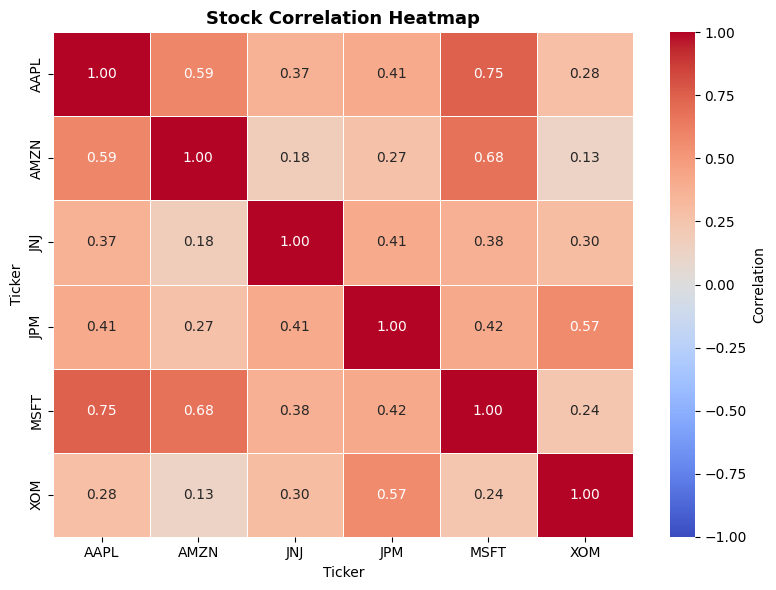

In [58]:
returns = data.pct_change().dropna()

corr_matrix = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation'})
plt.title("Stock Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

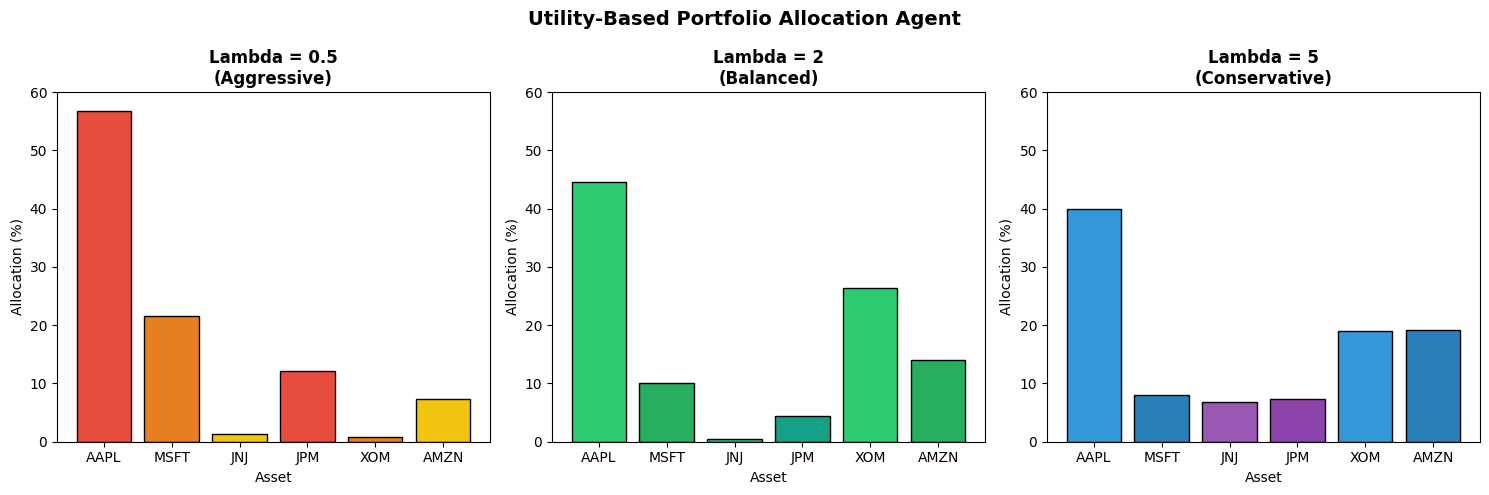

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

lambda_labels = ["Lambda = 0.5\n(Aggressive)", "Lambda = 2\n(Balanced)", "Lambda = 5\n(Conservative)"]
colors = [
    ['#e74c3c', '#e67e22', '#f1c40f', '#e74c3c', '#e67e22', '#f1c40f'],
    ['#2ecc71', '#27ae60', '#1abc9c', '#16a085', '#2ecc71', '#27ae60'],
    ['#3498db', '#2980b9', '#9b59b6', '#8e44ad', '#3498db', '#2980b9'],
]

for idx, (lambda_, result) in enumerate(best_results.items()):
    axes[idx].bar(tickers, result['weights'] * 100, color=colors[idx], edgecolor='black')
    axes[idx].set_title(lambda_labels[idx], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Asset")
    axes[idx].set_ylabel("Allocation (%)")
    axes[idx].set_ylim(0, 60)

plt.suptitle("Utility-Based Portfolio Allocation Agent", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("portfolio_allocation.png", dpi=150)
plt.show()

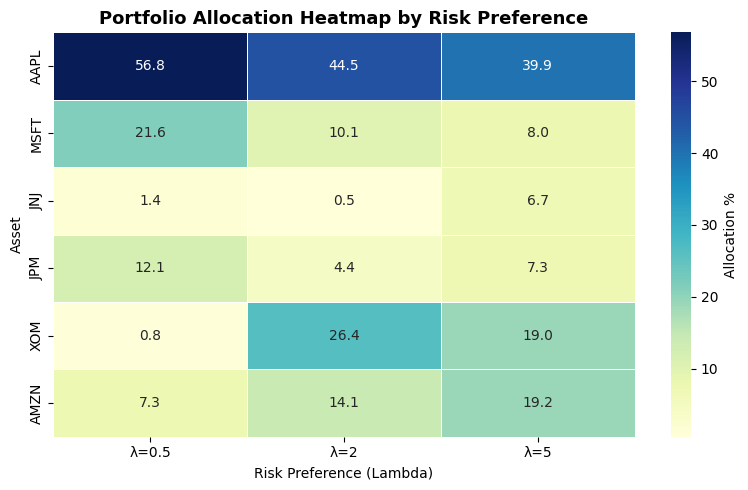

In [60]:
heatmap_data = pd.DataFrame(
    {f"λ={l}": best_results[l]['weights'] for l in best_results},
    index=tickers
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={'label': 'Allocation %'})
plt.title("Portfolio Allocation Heatmap by Risk Preference", fontsize=13, fontweight='bold')
plt.ylabel("Asset")
plt.xlabel("Risk Preference (Lambda)")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

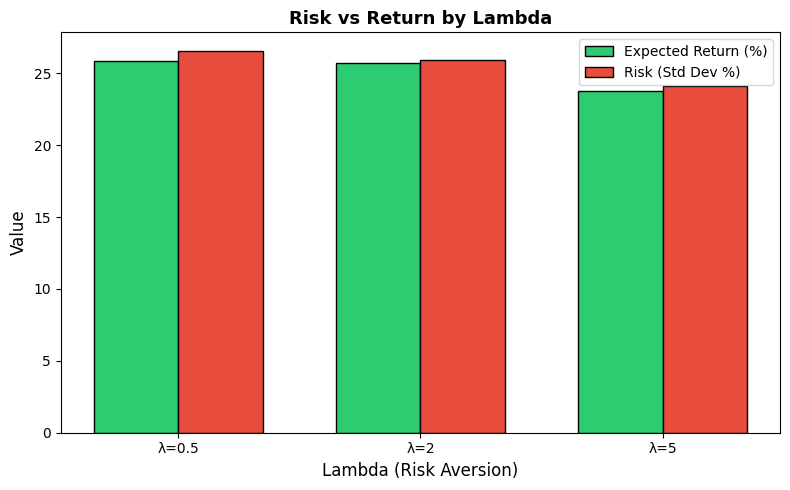

In [61]:
lambdas = list(best_results.keys())
ret_values = [best_results[l]['return'] * 100 for l in lambdas]
risk_values = [np.sqrt(best_results[l]['risk']) * 100 for l in lambdas]

x = np.arange(len(lambdas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, ret_values, width, label='Expected Return (%)', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, risk_values, width, label='Risk (Std Dev %)', color='#e74c3c', edgecolor='black')

ax.set_xlabel("Lambda (Risk Aversion)", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Risk vs Return by Lambda", fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"λ={l}" for l in lambdas])
ax.legend()
plt.tight_layout()
plt.savefig("risk_vs_return.png", dpi=150)
plt.show()

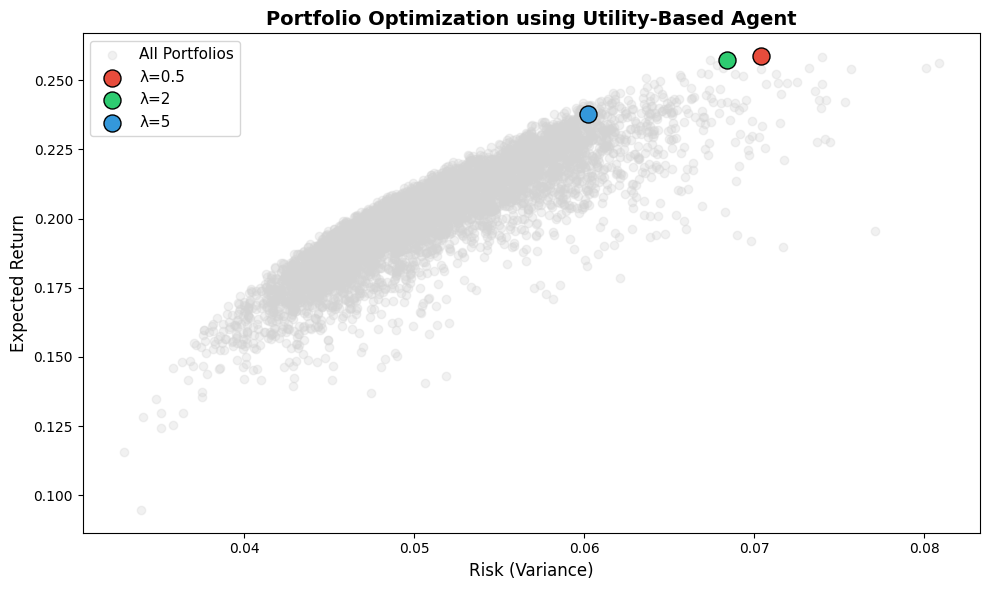

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, alpha=0.3, color='lightgray', label='All Portfolios')

colors = ['#e74c3c', '#2ecc71', '#3498db']
offsets = [0, 0.001, 0.002]

for (lambda_, result), color, offset in zip(best_results.items(), colors, offsets):
    plt.scatter(result["risk"] + offset, result["return"],
                label=f"λ={lambda_}", s=150, color=color, edgecolor='black', zorder=5)

plt.xlabel("Risk (Variance)", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)
plt.title("Portfolio Optimization using Utility-Based Agent", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150)
plt.show()